# 🌊 Flood Prediction — End-to-End Machine Learning Project

This notebook implements the full project workflow across all epics:

1. **Epic 1 — Data Collection**
2. **Epic 2 — Visualizing and Analysing the Data**
3. **Epic 3 — Data Pre-Processing**
4. **Epic 4 — Model Building**

The trained model produced here is consumed by the Flask web application in `app/` (**Epic 5**).


## Epic 1 — Data Collection
### Story 1.1: Download the flood prediction dataset and load it into the notebook

The dataset (`flood_dataset.csv`) contains 6,000 records describing monsoon, hydrological,
terrain, land-use and socio-infrastructure factors, along with the binary target
`Flood_Occurred` (1 = flood occurred, 0 = no flood). It was assembled from public
flood-risk—factor definitions (rainfall, river discharge, water level, drainage,
historical flood counts, infrastructure/land-cover quality, etc.).


In [1]:
import pandas as pd

DATA_PATH = "../data/flood_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (6000, 17)


,Record_ID,MonsoonIntensity,Rainfall_mm,Temperature_C,Humidity_pct,River_Discharge_m3s,Water_Level_m,Elevation_m,Land_Cover,Soil_Type,Population_Density,Infrastructure_Quality,Drainage_Quality_Score,Historical_Floods_Count,Deforestation_Index,Climate_Change_Index,Flood_Occurred
0,1,4.37,101.7,33.9,78.1,425.8,3.87,181.7,Forest,Loamy,947.0,Average,4.53,0,5.79,4.76,0
1,2,6.45,201.6,23.4,67.4,234.3,5.30,95.9,Urban,Silty,226.0,Good,6.41,2,2.21,6.53,1
2,3,6.50,120.3,25.1,66.3,797.7,5.72,128.9,Urban,Loamy,991.0,Poor,7.80,2,8.89,2.77,1
3,4,4.96,165.0,31.7,67.3,558.2,4.68,164.1,Urban,Clay,501.0,Good,5.27,2,7.20,4.56,1
4,5,6.22,235.7,27.2,64.6,329.1,5.00,70.3,Wetland,Loamy,1132.0,Average,3.47,0,7.93,5.07,1


## Epic 2 — Visualizing and Analysing the Data
### Story 2.1: Import all required Python libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

import os
os.makedirs("../results", exist_ok=True)
print("Libraries imported.")


Libraries imported.


### Story 2.2: Read and explore the dataset (structure, features, target)

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (6000, 17)
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Record_ID                6000 non-null   int64  
 1   MonsoonIntensity         6000 non-null   float64
 2   Rainfall_mm              5820 non-null   float64
 3   Temperature_C            6000 non-null   float64
 4   Humidity_pct             5880 non-null   float64
 5   River_Discharge_m3s      6000 non-null   float64
 6   Water_Level_m            5850 non-null   float64
 7   Elevation_m              6000 non-null   float64
 8   Land_Cover               6000 non-null   str    
 9   Soil_Type                6000 non-null   str    
 10  Population_Density       6000 non-null   float64
 11  Infrastructure_Quality   5910 non-null   str    
 12  Drainage_Quality_Score   5880 non-null   float64
 13  Historical_Floods_Count  6000 non-null   int64  
 14  Deforestation_Ind

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Record_ID,6000.0,NaN,NaN,NaN,3000.5,1732.195139,1.0,1500.75,3000.5,4500.25,6000.0
MonsoonIntensity,6000.0,NaN,NaN,NaN,4.992585,2.148167,0.0,3.54,5.005,6.4425,10.0
Rainfall_mm,5820.0,NaN,NaN,NaN,164.089417,91.904202,7.6,103.6,147.8,206.4,1720.088547
Temperature_C,6000.0,NaN,NaN,NaN,27.004117,4.008095,11.6,24.3,27.0,29.8,42.8
Humidity_pct,5880.0,NaN,NaN,NaN,69.891003,11.731759,28.1,61.7,70.0,77.9,100.0
River_Discharge_m3s,6000.0,NaN,NaN,NaN,450.219952,274.173628,16.1,253.075,397.6,589.35,3943.489161
Water_Level_m,5850.0,NaN,NaN,NaN,4.56305,1.956933,0.0,3.24,4.56,5.91,11.57
Elevation_m,6000.0,NaN,NaN,NaN,149.331017,148.721013,0.0,44.175,102.5,207.325,1200.0
Land_Cover,6000,5,Agricultural,1847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil_Type,6000,4,Clay,1808,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Target variable distribution:")
print(df['Flood_Occurred'].value_counts())
print(df['Flood_Occurred'].value_counts(normalize=True).round(3) * 100, "%")


Target variable distribution:
Flood_Occurred
0    3840
1    2160
Name: count, dtype: int64
Flood_Occurred
0    64.0
1    36.0
Name: proportion, dtype: float64 %


### Story 2.3: Univariate analysis — distribution of individual variables

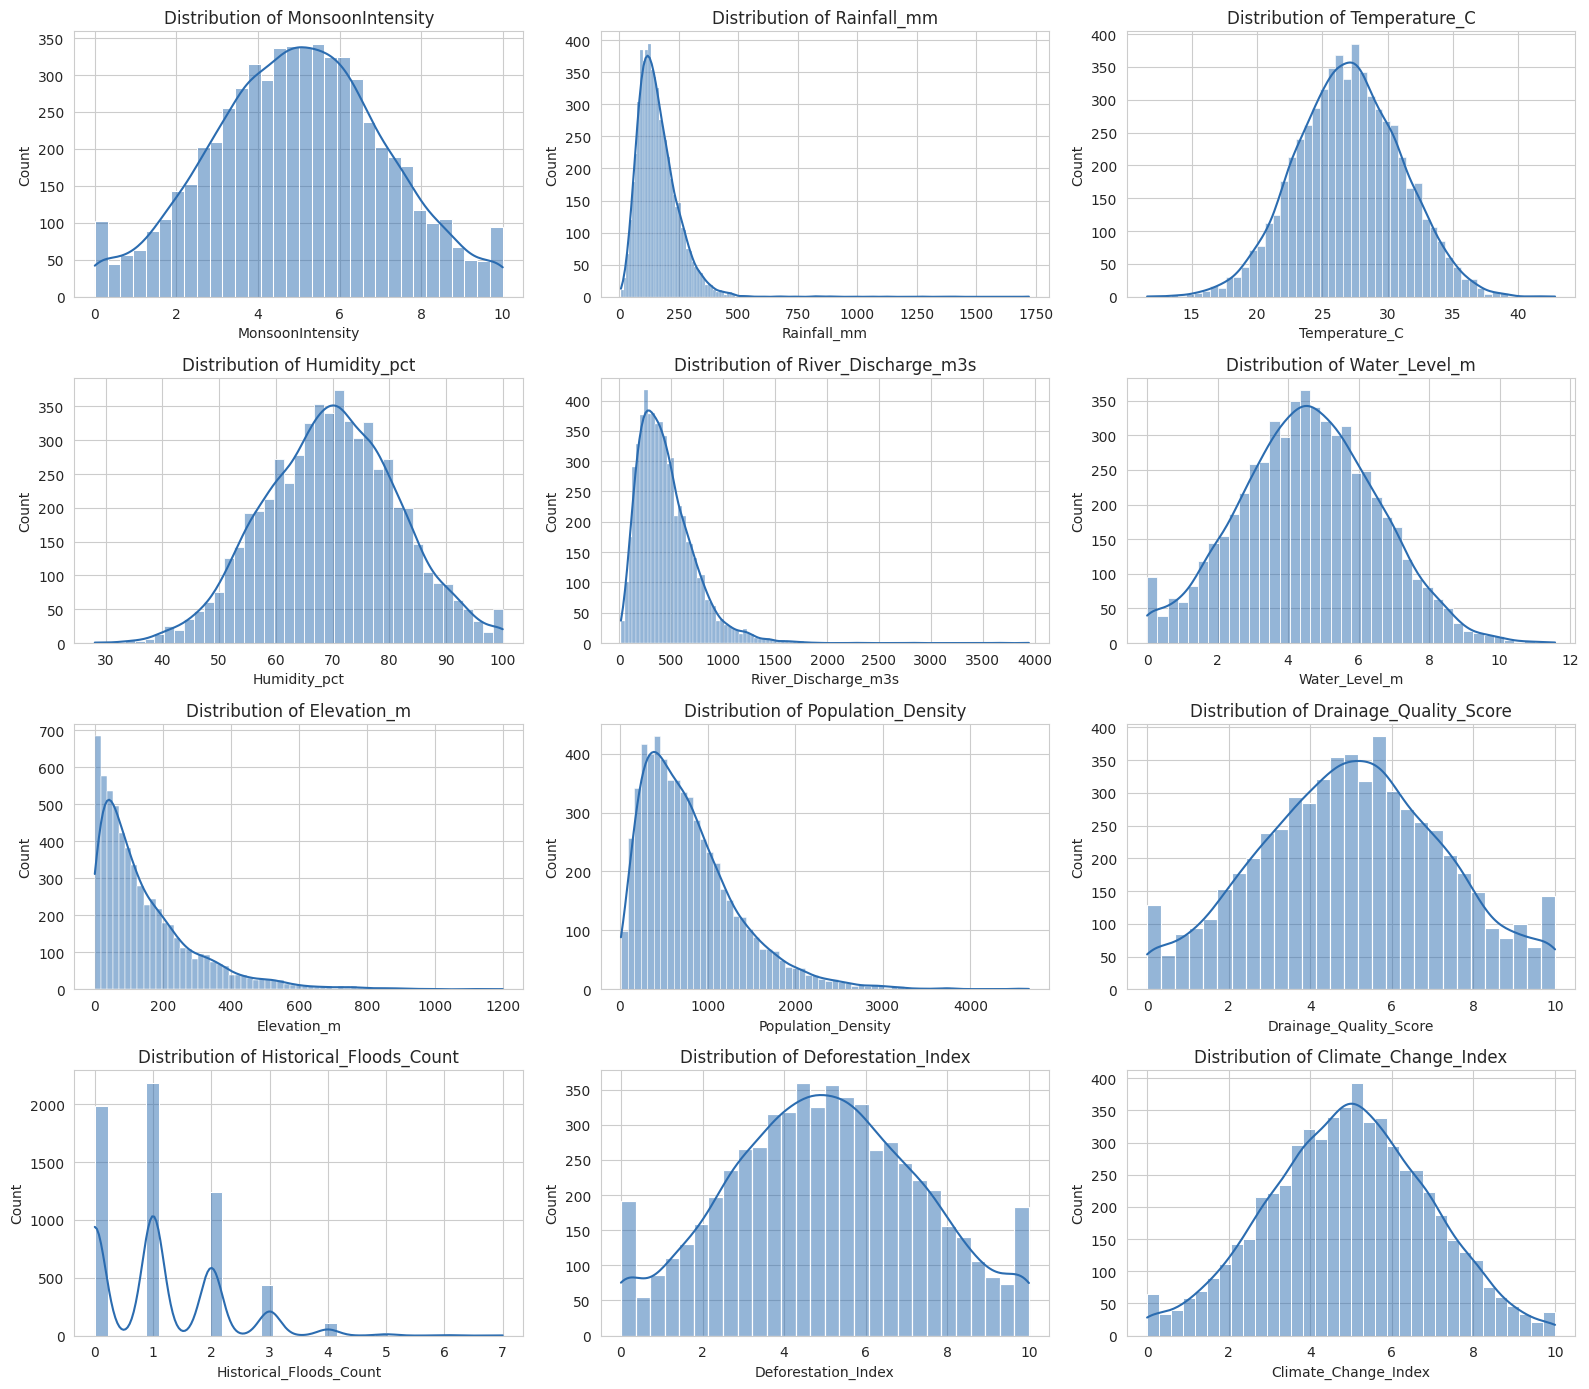

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['Record_ID', 'Flood_Occurred'])

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#2b6cb0")
    axes[i].set_title(f"Distribution of {col}")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("../results/01_univariate_histograms.png", bbox_inches="tight")
plt.show()


/tmp/ipykernel_566/4076936239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="Blues_d",
/tmp/ipykernel_566/4076936239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="Blues_d",
/tmp/ipykernel_566/4076936239.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="Blues_d",


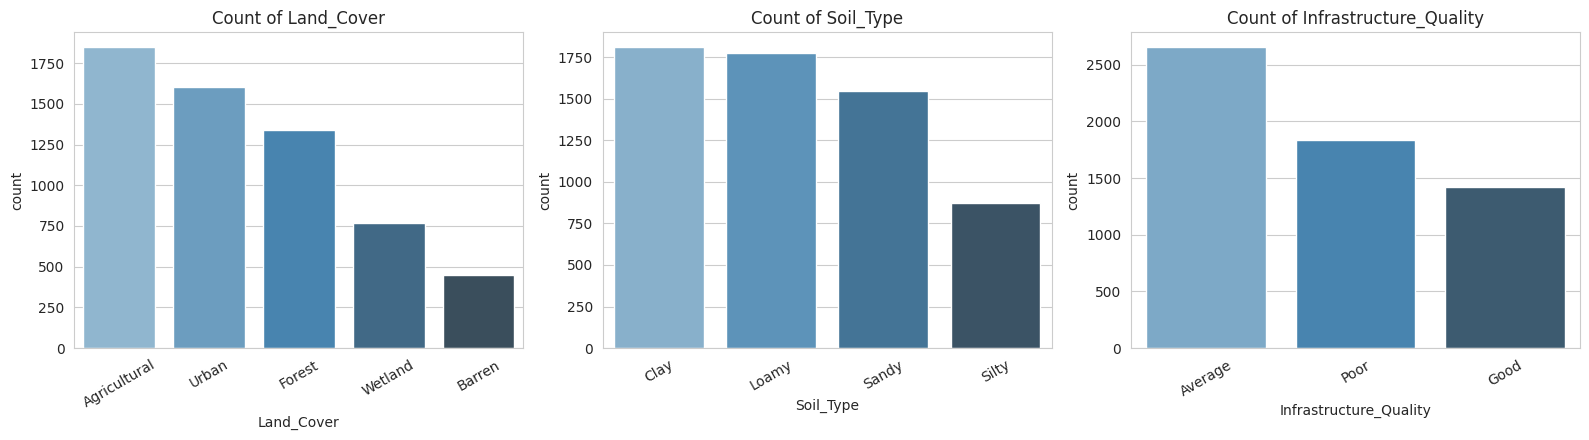

In [7]:
categorical_cols = ['Land_Cover', 'Soil_Type', 'Infrastructure_Quality']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette="Blues_d",
                   order=df[col].value_counts().index)
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("../results/02_univariate_categorical.png", bbox_inches="tight")
plt.show()


/tmp/ipykernel_566/2141017925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Flood_Occurred", palette=["#2b6cb0", "#e53e3e"])


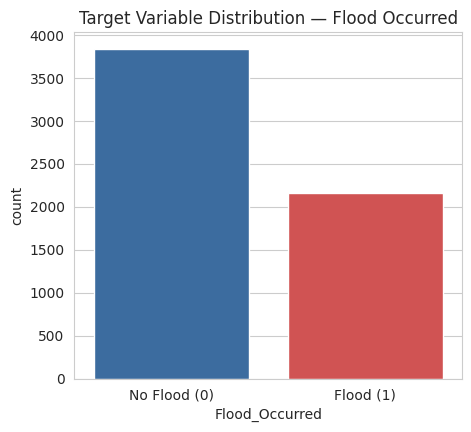

In [8]:
plt.figure(figsize=(5, 4.5))
sns.countplot(data=df, x="Flood_Occurred", palette=["#2b6cb0", "#e53e3e"])
plt.title("Target Variable Distribution — Flood Occurred")
plt.xticks([0, 1], ["No Flood (0)", "Flood (1)"])
plt.savefig("../results/03_target_distribution.png", bbox_inches="tight")
plt.show()


### Story 2.4: Multivariate analysis — relationships between features

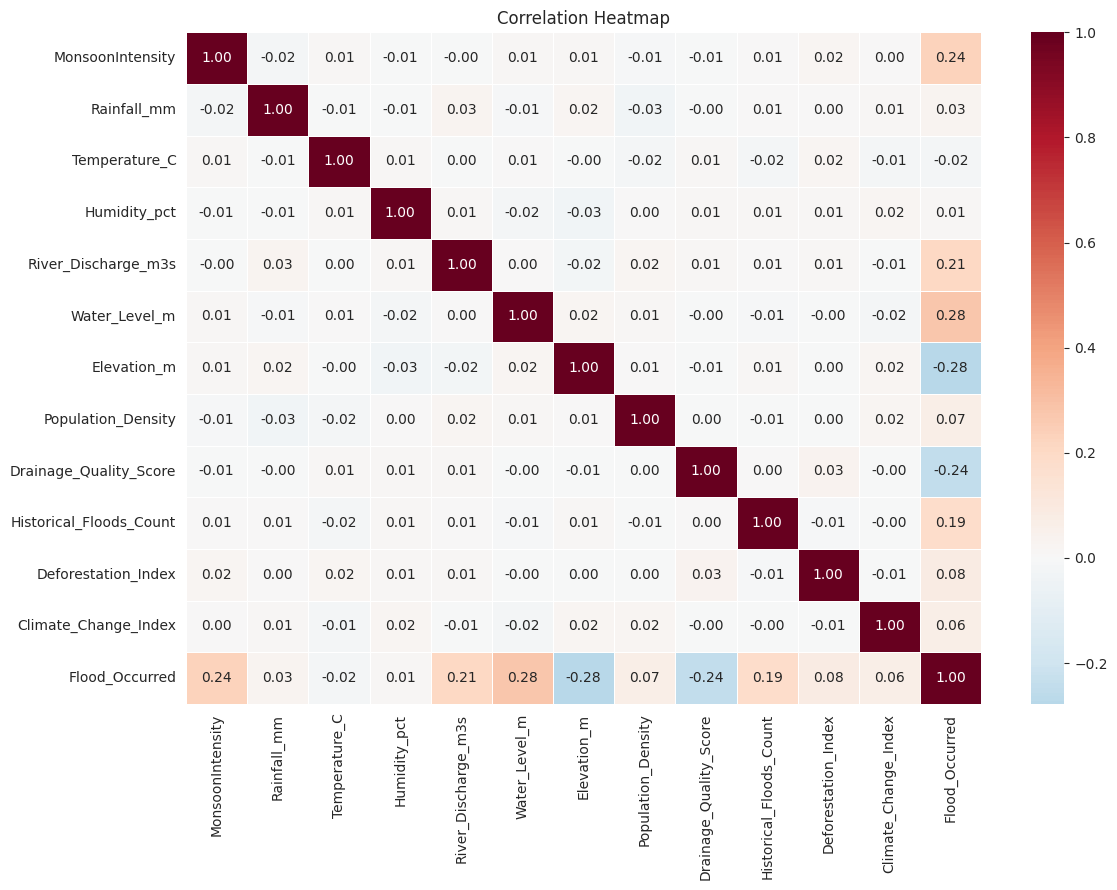

In [9]:
plt.figure(figsize=(12, 9))
corr = df[numeric_cols.tolist() + ['Flood_Occurred']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.4)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../results/04_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [10]:
top_corr = corr['Flood_Occurred'].drop('Flood_Occurred').sort_values(key=abs, ascending=False)
print("Features most correlated with Flood_Occurred:")
top_corr


Features most correlated with Flood_Occurred:


Water_Level_m              0.278077
Elevation_m               -0.277751
Drainage_Quality_Score    -0.239912
MonsoonIntensity           0.235118
River_Discharge_m3s        0.208856
Historical_Floods_Count    0.185623
Deforestation_Index        0.084716
Population_Density         0.069749
Climate_Change_Index       0.063903
Rainfall_mm                0.026912
Temperature_C             -0.016781
Humidity_pct               0.009669
Name: Flood_Occurred, dtype: float64

/tmp/ipykernel_566/537703594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Flood_Occurred', y=col, ax=axes[i], palette=["#2b6cb0", "#e53e3e"])
/tmp/ipykernel_566/537703594.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Flood", "Flood"])
/tmp/ipykernel_566/537703594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Flood_Occurred', y=col, ax=axes[i], palette=["#2b6cb0", "#e53e3e"])
/tmp/ipykernel_566/537703594.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

/tmp/ipykernel_566/537703594.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No Flood", "Flood"])


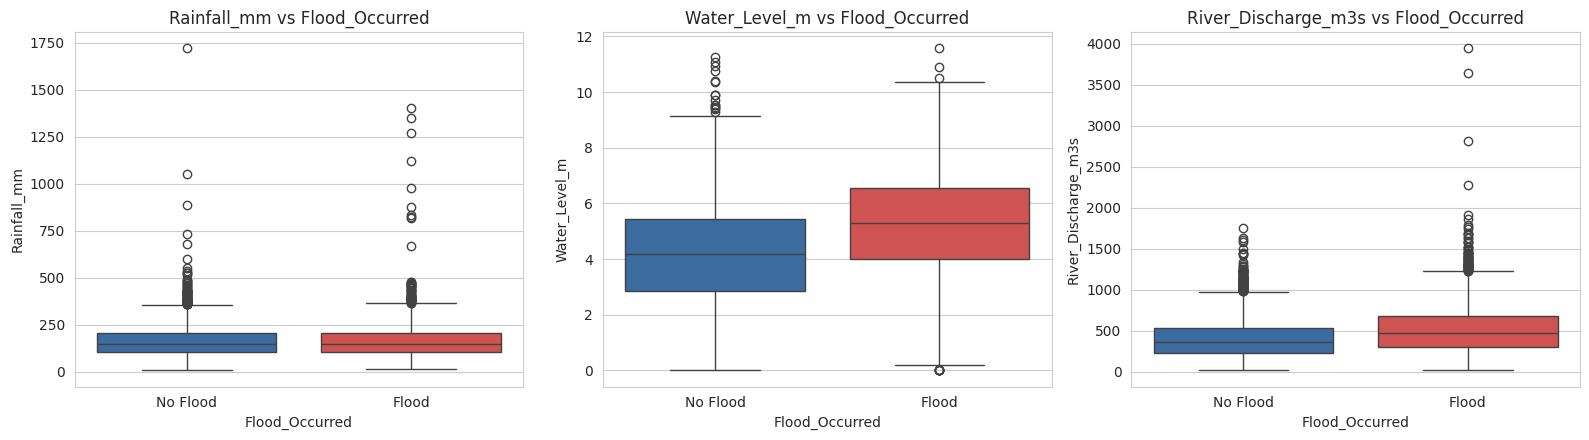

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(['Rainfall_mm', 'Water_Level_m', 'River_Discharge_m3s']):
    sns.boxplot(data=df, x='Flood_Occurred', y=col, ax=axes[i], palette=["#2b6cb0", "#e53e3e"])
    axes[i].set_title(f"{col} vs Flood_Occurred")
    axes[i].set_xticklabels(["No Flood", "Flood"])
plt.tight_layout()
plt.savefig("../results/05_multivariate_boxplots.png", bbox_inches="tight")
plt.show()


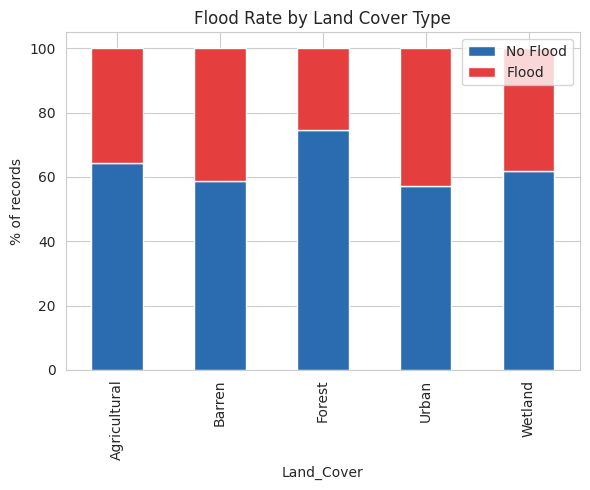

In [12]:
plt.figure(figsize=(6, 5))
ct = pd.crosstab(df['Land_Cover'], df['Flood_Occurred'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=["#2b6cb0", "#e53e3e"], ax=plt.gca())
plt.ylabel("% of records")
plt.title("Flood Rate by Land Cover Type")
plt.legend(["No Flood", "Flood"])
plt.tight_layout()
plt.savefig("../results/06_landcover_vs_flood.png", bbox_inches="tight")
plt.show()


### Story 2.5: Descriptive statistical analysis

In [13]:
desc_stats = df[numeric_cols].describe().T
desc_stats['skew'] = df[numeric_cols].skew()
desc_stats['kurtosis'] = df[numeric_cols].kurtosis()
desc_stats.to_csv("../results/07_descriptive_statistics.csv")
desc_stats


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
MonsoonIntensity,6000.0,4.992585,2.148167,0.0,3.540,5.005,6.4425,10.000000,-0.004735,-0.334315
Rainfall_mm,5820.0,164.089417,91.904202,7.6,103.600,147.800,206.4000,1720.088547,3.444053,35.374752
Temperature_C,6000.0,27.004117,4.008095,11.6,24.300,27.000,29.8000,42.800000,-0.002059,-0.013382
Humidity_pct,5880.0,69.891003,11.731759,28.1,61.700,70.000,77.9000,100.000000,-0.019149,-0.170920
River_Discharge_m3s,6000.0,450.219952,274.173628,16.1,253.075,397.600,589.3500,3943.489161,1.851377,10.202287
Water_Level_m,5850.0,4.563050,1.956933,0.0,3.240,4.560,5.9100,11.570000,0.030133,-0.194355
Elevation_m,6000.0,149.331017,148.721013,0.0,44.175,102.500,207.3250,1200.000000,1.941948,5.309558
Population_Density,6000.0,799.990500,564.835846,12.0,385.000,679.000,1071.2500,4667.000000,1.499922,3.632351
Drainage_Quality_Score,5880.0,5.025066,2.278843,0.0,3.440,5.040,6.6000,10.000000,0.008641,-0.448160
Historical_Floods_Count,6000.0,1.103833,1.050826,0.0,0.000,1.000,2.0000,7.000000,0.993983,1.252080


## Epic 3 — Data Pre-Processing
### Story 3.1: Identify and handle missing values

In [14]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_summary)


                        missing_count  missing_pct
Rainfall_mm                       180          3.0
Water_Level_m                     150          2.5
Humidity_pct                      120          2.0
Drainage_Quality_Score            120          2.0
Infrastructure_Quality             90          1.5


In [15]:
df_clean = df.drop(columns=['Record_ID']).copy()

# Numeric columns -> median imputation (robust to outliers/skew)
num_missing_cols = df_clean.select_dtypes(include=[np.number]).columns[df_clean.select_dtypes(include=[np.number]).isnull().any()]
for col in num_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns -> mode imputation
cat_missing_cols = df_clean.select_dtypes(include='object').columns[df_clean.select_dtypes(include='object').isnull().any()]
for col in cat_missing_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Remaining missing values after imputation:", df_clean.isnull().sum().sum())


Remaining missing values after imputation: 0


/tmp/ipykernel_566/2574048508.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_missing_cols = df_clean.select_dtypes(include='object').columns[df_clean.select_dtypes(include='object').isnull().any()]
/tmp/ipykernel_566/2574048508.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/use

### Story 3.2: Detect and treat outliers

In [16]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_report = {}
for col in numeric_cols:
    low, high = iqr_bounds(df_clean[col])
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    outlier_report[col] = n_out
outlier_report = pd.Series(outlier_report).sort_values(ascending=False)
print("Outlier counts per numeric feature (IQR method):")
print(outlier_report[outlier_report > 0])


Outlier counts per numeric feature (IQR method):
Elevation_m                288
Population_Density         191
River_Discharge_m3s        168
Rainfall_mm                157
Temperature_C               38
Water_Level_m               28
Humidity_pct                15
Historical_Floods_Count     11
dtype: int64


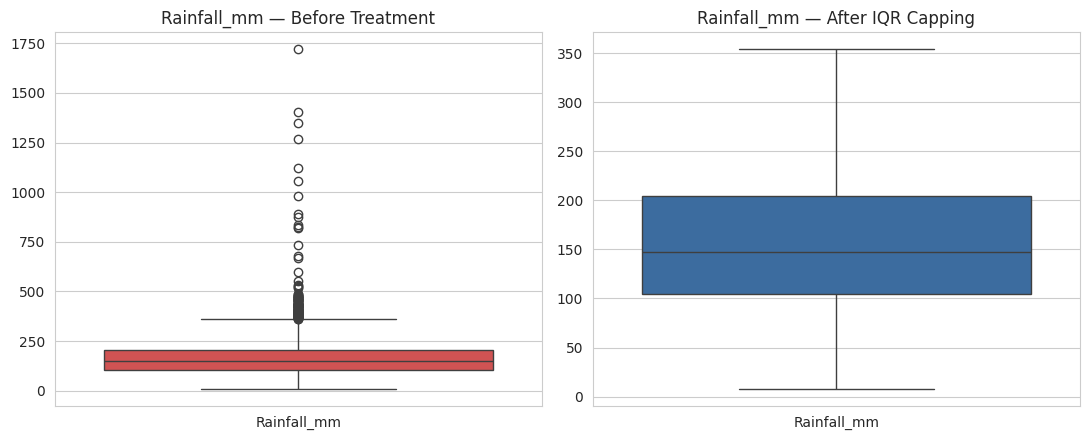

In [17]:
# Cap outliers at the IQR fences (winsorization) - preserves records, reduces distortion
for col in numeric_cols:
    low, high = iqr_bounds(df_clean[col])
    df_clean[col] = df_clean[col].clip(lower=low, upper=high)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df[['Rainfall_mm']], ax=axes[0], color="#e53e3e")
axes[0].set_title("Rainfall_mm — Before Treatment")
sns.boxplot(data=df_clean[['Rainfall_mm']], ax=axes[1], color="#2b6cb0")
axes[1].set_title("Rainfall_mm — After IQR Capping")
plt.tight_layout()
plt.savefig("../results/08_outlier_treatment.png", bbox_inches="tight")
plt.show()


### Story 3.3: Convert categorical variables into numerical representations

In [18]:
from sklearn.preprocessing import LabelEncoder

categorical_cols_all = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols_all)

label_encoders = {}
for col in categorical_cols_all:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Categorical columns to encode: ['Land_Cover', 'Soil_Type', 'Infrastructure_Quality']
Land_Cover: {'Agricultural': np.int64(0), 'Barren': np.int64(1), 'Forest': np.int64(2), 'Urban': np.int64(3), 'Wetland': np.int64(4)}
Soil_Type: {'Clay': np.int64(0), 'Loamy': np.int64(1), 'Sandy': np.int64(2), 'Silty': np.int64(3)}
Infrastructure_Quality: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}


/tmp/ipykernel_566/3593649242.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_all = df_clean.select_dtypes(include='object').columns.tolist()


### Story 3.4: Split the dataset into training and testing subsets

In [19]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Flood_Occurred'])
y = df_clean['Flood_Occurred']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set:", X_train.shape, " Testing set:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test target balance:\n", y_test.value_counts(normalize=True).round(3))


Training set: (4800, 15)  Testing set: (1200, 15)
Train target balance:
 Flood_Occurred
0    0.64
1    0.36
Name: proportion, dtype: float64
Test target balance:
 Flood_Occurred
0    0.64
1    0.36
Name: proportion, dtype: float64


### Story 3.5: Apply feature scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']].round(3).head()


,mean,std
MonsoonIntensity,-0.0,1.0
Rainfall_mm,0.0,1.0
Temperature_C,-0.0,1.0
Humidity_pct,0.0,1.0
River_Discharge_m3s,-0.0,1.0


## Epic 4 — Model Building
### Story 4.1: Decision Tree

===== Decision Tree =====
Accuracy: 0.7542
Precision: 0.6827
Recall: 0.5926
F1_Score: 0.6344
ROC_AUC: 0.7772

              precision    recall  f1-score   support

    No Flood       0.79      0.85      0.81       768
       Flood       0.68      0.59      0.63       432

    accuracy                           0.75      1200
   macro avg       0.73      0.72      0.72      1200
weighted avg       0.75      0.75      0.75      1200



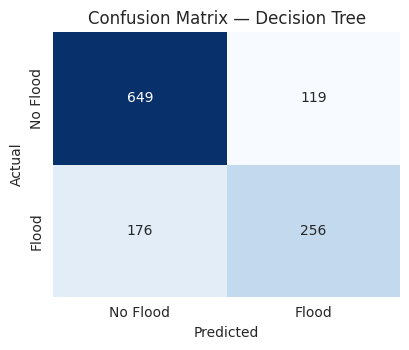

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

results = {}
fitted_models = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, needs_scaled=False):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred

    metrics = {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1_Score": f1_score(y_te, y_pred),
        "ROC_AUC": roc_auc_score(y_te, y_proba),
    }
    results[name] = metrics
    fitted_models[name] = model

    print(f"===== {name} =====")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=["No Flood", "Flood"]))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No Flood", "Flood"], yticklabels=["No Flood", "Flood"])
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    safe_name = name.lower().replace(" ", "_")
    plt.savefig(f"../results/cm_{safe_name}.png", bbox_inches="tight")
    plt.show()
    return metrics

dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42)
_ = evaluate_model("Decision Tree", dt_model, X_train, X_test, y_train, y_test)


### Story 4.2: Random Forest

===== Random Forest =====
Accuracy: 0.8158
Precision: 0.8651
Recall: 0.5787
F1_Score: 0.6935
ROC_AUC: 0.8893

              precision    recall  f1-score   support

    No Flood       0.80      0.95      0.87       768
       Flood       0.87      0.58      0.69       432

    accuracy                           0.82      1200
   macro avg       0.83      0.76      0.78      1200
weighted avg       0.82      0.82      0.81      1200



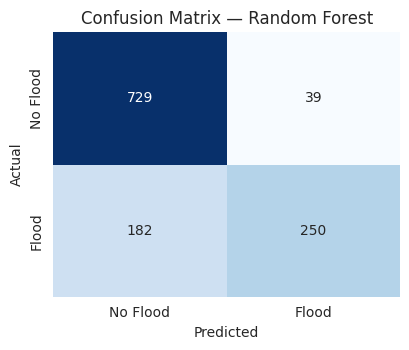

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                   random_state=42, n_jobs=-1)
_ = evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test)


### Story 4.3: K-Nearest Neighbors (KNN)

KNN is distance-based, so it is trained on the **scaled** features.

===== KNN =====
Accuracy: 0.7683
Precision: 0.7770
Recall: 0.5000
F1_Score: 0.6085
ROC_AUC: 0.8288

              precision    recall  f1-score   support

    No Flood       0.77      0.92      0.84       768
       Flood       0.78      0.50      0.61       432

    accuracy                           0.77      1200
   macro avg       0.77      0.71      0.72      1200
weighted avg       0.77      0.77      0.75      1200



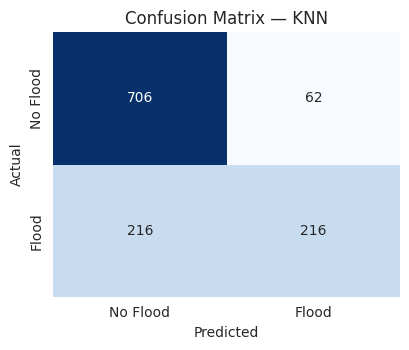

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=15, weights="distance")
_ = evaluate_model("KNN", knn_model, X_train_scaled, X_test_scaled, y_train, y_test)


### Story 4.4: XGBoost

===== XGBoost =====
Accuracy: 0.8383
Precision: 0.8251
Recall: 0.6991
F1_Score: 0.7569
ROC_AUC: 0.9063

              precision    recall  f1-score   support

    No Flood       0.84      0.92      0.88       768
       Flood       0.83      0.70      0.76       432

    accuracy                           0.84      1200
   macro avg       0.83      0.81      0.82      1200
weighted avg       0.84      0.84      0.83      1200



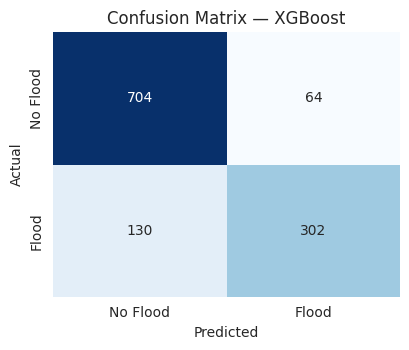

In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    eval_metric="logloss", random_state=42, n_jobs=-1
)
_ = evaluate_model("XGBoost", xgb_model, X_train, X_test, y_train, y_test)


### Story 4.5: Compare the performance of all developed models

In [25]:
results_df = pd.DataFrame(results).T.sort_values("F1_Score", ascending=False)
results_df.to_csv("../results/09_model_comparison.csv")
results_df.round(4)


,Accuracy,Precision,Recall,F1_Score,ROC_AUC
XGBoost,0.8383,0.8251,0.6991,0.7569,0.9063
Random Forest,0.8158,0.8651,0.5787,0.6935,0.8893
Decision Tree,0.7542,0.6827,0.5926,0.6344,0.7772
KNN,0.7683,0.7770,0.5000,0.6085,0.8288


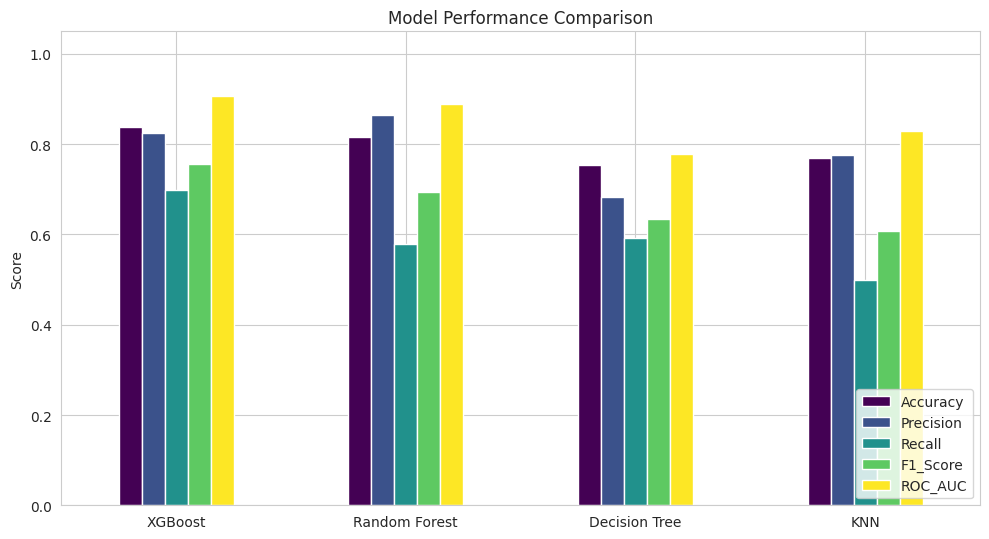

In [26]:
fig, ax = plt.subplots(figsize=(10, 5.5))
results_df[['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']].plot(
    kind='bar', ax=ax, colormap='viridis'
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/10_model_comparison_chart.png", bbox_inches="tight")
plt.show()


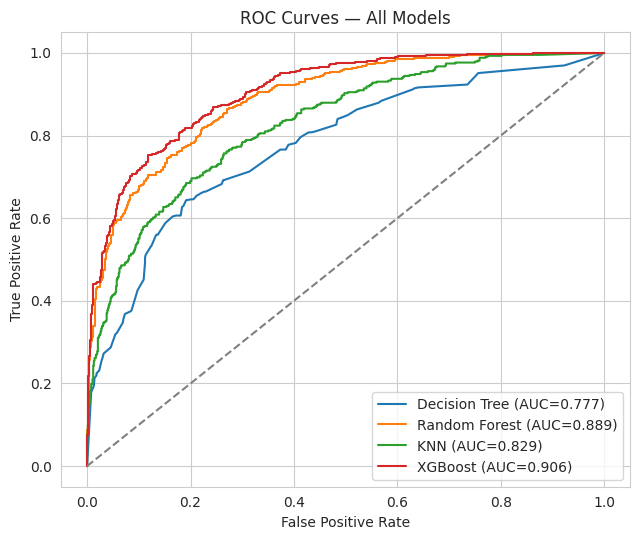

In [27]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(6.5, 5.5))
for name, model in fitted_models.items():
    X_te = X_test_scaled if name == "KNN" else X_test
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC_AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.savefig("../results/11_roc_curves.png", bbox_inches="tight")
plt.show()


### Story 4.6: Select the best-performing model and save it for deployment

The model with the highest **F1-score** (balances precision and recall — important for
flood risk, where both false alarms and missed floods carry a cost) is selected as the
final production model.

In [28]:
best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]
uses_scaled_input = (best_model_name == "KNN")

print(f"Best performing model: {best_model_name}")
print(results_df.loc[best_model_name].round(4))


Best performing model: XGBoost
Accuracy     0.8383
Precision    0.8251
Recall       0.6991
F1_Score     0.7569
ROC_AUC      0.9063
Name: XGBoost, dtype: float64


/tmp/ipykernel_566/3899185411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi.values[:12], y=fi.index[:12], palette="viridis")


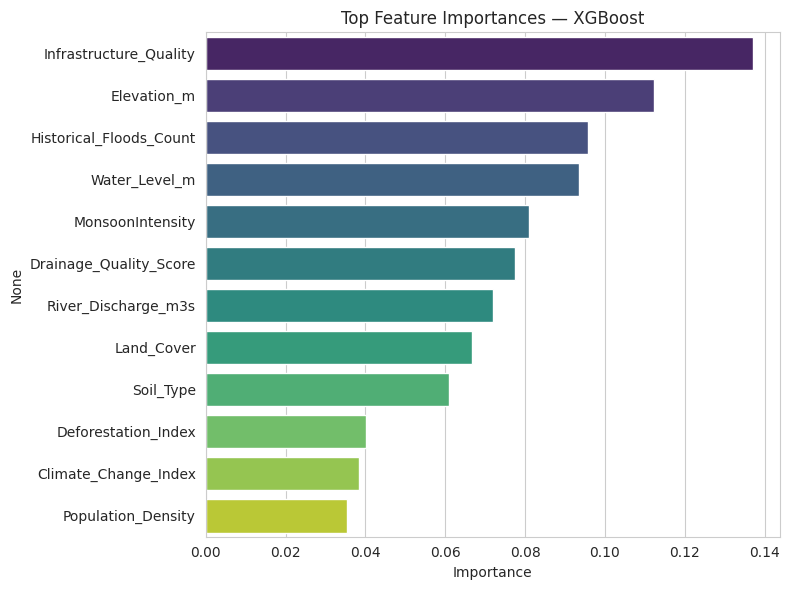

In [29]:
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values[:12], y=fi.index[:12], palette="viridis")
    plt.title(f"Top Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../results/12_feature_importance.png", bbox_inches="tight")
    plt.show()
    fi.to_csv("../results/13_feature_importance.csv")


In [30]:
import pickle
import json

MODEL_DIR = "../model"
import os
os.makedirs(MODEL_DIR, exist_ok=True)

with open(f"{MODEL_DIR}/flood_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(f"{MODEL_DIR}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(f"{MODEL_DIR}/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

model_meta = {
    "best_model_name": best_model_name,
    "uses_scaled_input": uses_scaled_input,
    "feature_order": list(X_train.columns),
    "categorical_columns": categorical_cols_all,
    "metrics": {k: round(v, 4) for k, v in results[best_model_name].items()},
    "all_model_results": {m: {k: round(v, 4) for k, v in mets.items()} for m, mets in results.items()},
}
with open(f"{MODEL_DIR}/model_metadata.json", "w") as f:
    json.dump(model_meta, f, indent=2)

print("Saved model, scaler, encoders and metadata to", MODEL_DIR)
print(json.dumps(model_meta, indent=2))


Saved model, scaler, encoders and metadata to ../model
{
  "best_model_name": "XGBoost",
  "uses_scaled_input": false,
  "feature_order": [
    "MonsoonIntensity",
    "Rainfall_mm",
    "Temperature_C",
    "Humidity_pct",
    "River_Discharge_m3s",
    "Water_Level_m",
    "Elevation_m",
    "Land_Cover",
    "Soil_Type",
    "Population_Density",
    "Infrastructure_Quality",
    "Drainage_Quality_Score",
    "Historical_Floods_Count",
    "Deforestation_Index",
    "Climate_Change_Index"
  ],
  "categorical_columns": [
    "Land_Cover",
    "Soil_Type",
    "Infrastructure_Quality"
  ],
  "metrics": {
    "Accuracy": 0.8383,
    "Precision": 0.8251,
    "Recall": 0.6991,
    "F1_Score": 0.7569,
    "ROC_AUC": 0.9063
  },
  "all_model_results": {
    "Decision Tree": {
      "Accuracy": 0.7542,
      "Precision": 0.6827,
      "Recall": 0.5926,
      "F1_Score": 0.6344,
      "ROC_AUC": 0.7772
    },
    "Random Forest": {
      "Accuracy": 0.8158,
      "Precision": 0.8651,
      "